In [ ]:
# 1. Import Necessary Libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- Starting Task 1: Iris Classification ---\n")

# 2. Load and Prepare the Dataset
iris = load_iris()
# Convert to a pandas DataFrame for better readability
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map the numerical targets (0, 1, 2) back to actual flower names for clarity
target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['species_name'] = df['species'].map(target_names)

print("Sample of the data we are feeding the model:")
print(df.head(), "\n")

# 3. Split Data into Features (X) and Target (y)
X = df.drop(columns=['species', 'species_name']) # Features: Sepal/Petal lengths and widths
y = df['species'] # Target: The flower type

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
print("✅ Model Training Complete.\n")

# 5. Make Predictions and Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))

--- Starting Task 1: Iris Classification ---

Sample of the data we are feeding the model:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa   

✅ Model Training Complete.

🎯 Model Accuracy: 100.00%

Detailed Performance Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# Step 1: Load the messages and labels
# ---------------------------------------------------------
# We are using the publicly available UCI SMS Spam Collection
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# Read the tab-separated dataset
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Convert labels to binary numeric values (Spam = 1, Ham = 0)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset Preview:")
print(df.head(), "\n")

# ---------------------------------------------------------
# Step 2 & 3: Preprocess text and Convert to numeric features
# ---------------------------------------------------------
# scikit-learn's TfidfVectorizer handles lowercasing, stop word removal,
# tokenization, and TF-IDF conversion all in one step!
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english' # Removes common words like "the", "and", "is"
)

# Fit the vectorizer to the text and transform it into a sparse matrix
X = vectorizer.fit_transform(df['message'])
y = df['label_num']

print(f"Feature matrix shape: {X.shape} (Messages x Unique Words)\n")

# ---------------------------------------------------------
# Step 4: Split into train/test sets
# ---------------------------------------------------------
# 80% of data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# Step 5: Train a simple model
# ---------------------------------------------------------
# Multinomial Naive Bayes is highly effective and standard for text classification
model = MultinomialNB()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# Step 6: Measure performance
# ---------------------------------------------------------
# Predict the labels for the test set
predictions = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Generate a detailed classification report (Precision, Recall, F1-Score)
print("Detailed Performance Metrics:")
print(classification_report(y_test, predictions, target_names=['Ham', 'Spam']))

# ---------------------------------------------------------
# Bonus: Test it with your own text!
# ---------------------------------------------------------
def predict_spam(text):
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    return "SPAM" if prediction[0] == 1 else "HAM"

print("--- Custom Tests ---")
print("Test 1:", predict_spam("Hey, are we still meeting for lunch at 1?"))
print("Test 2:", predict_spam("CONGRATULATIONS! You've won a free $1000 gift card. Click here to claim now!"))

Dataset Preview:
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0 

Feature matrix shape: (5572, 8444) (Messages x Unique Words)

Model Accuracy: 97.94%

Detailed Performance Metrics:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

--- Custom Tests ---
Test 1: HAM
Test 2: SPAM


Loading California Housing Dataset...

--- First 5 rows of the dataset ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 

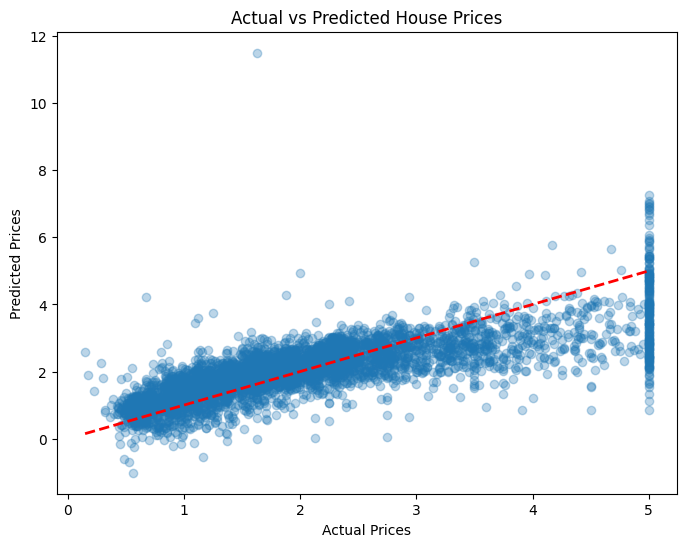

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# Step 1: Load the dataset and explore
# ==========================================
print("Loading California Housing Dataset...")
california = fetch_california_housing()

# Convert to a pandas DataFrame for easier exploration
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Price'] = california.target # Target variable (median house value in $100,000s)

print("\n--- First 5 rows of the dataset ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

# ==========================================
# Step 2: Handle missing data & preprocess
# ==========================================
# The California dataset doesn't have missing values natively,
# but if it did, we could use df.fillna() or df.dropna().

# Define our features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Normalize/Scale the features
# This ensures features with larger ranges (like population) don't dominate
# features with smaller ranges (like number of bedrooms).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# Step 3: Split into train/test sets
# ==========================================
# We use 80% of the data to train the model and 20% to test it.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# Step 4: Train a regression model
# ==========================================
print("\nTraining the Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)

# ==========================================
# Step 5: Evaluate predictions
# ==========================================
# Make predictions on the testing set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE) and R-squared
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error is often easier to interpret
r2 = r2_score(y_test, y_pred)

print(f"\n--- Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Visualize the actual vs. predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()